In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import pickle

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("fivethirtyeight")

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Read Dataset

data = pd.read_csv("../Dataset/loan_prediction.csv")

In [3]:
# Display First Five Rows

data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
# Shape of Dataset

data.shape

(614, 13)

In [5]:
# Dataset Information

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [6]:
# Statistical Summary

data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [7]:
# Check Missing Values

data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [8]:
# Display Column Names

data.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [9]:
# Data Types

data.dtypes

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

# Univariate Analysis

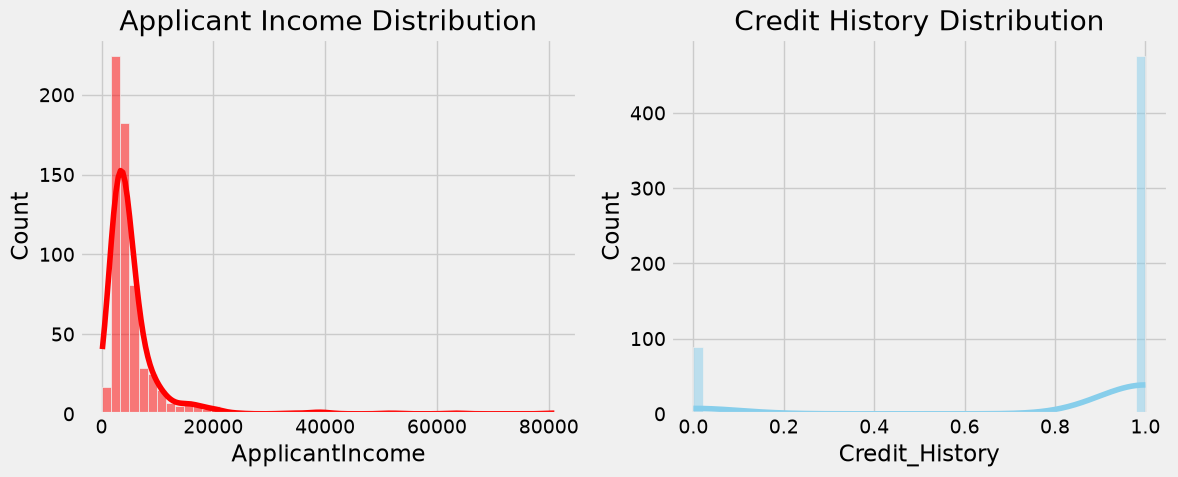

In [10]:
# Distribution Plot

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(data['ApplicantIncome'], kde=True, color='red')
plt.title("Applicant Income Distribution")

plt.subplot(1,2,2)
sns.histplot(data['Credit_History'], kde=True, color='skyblue')
plt.title("Credit History Distribution")

plt.tight_layout()
plt.show()

## Observation

- ApplicantIncome is positively skewed.
- Credit_History is a binary feature containing values 0 and 1.

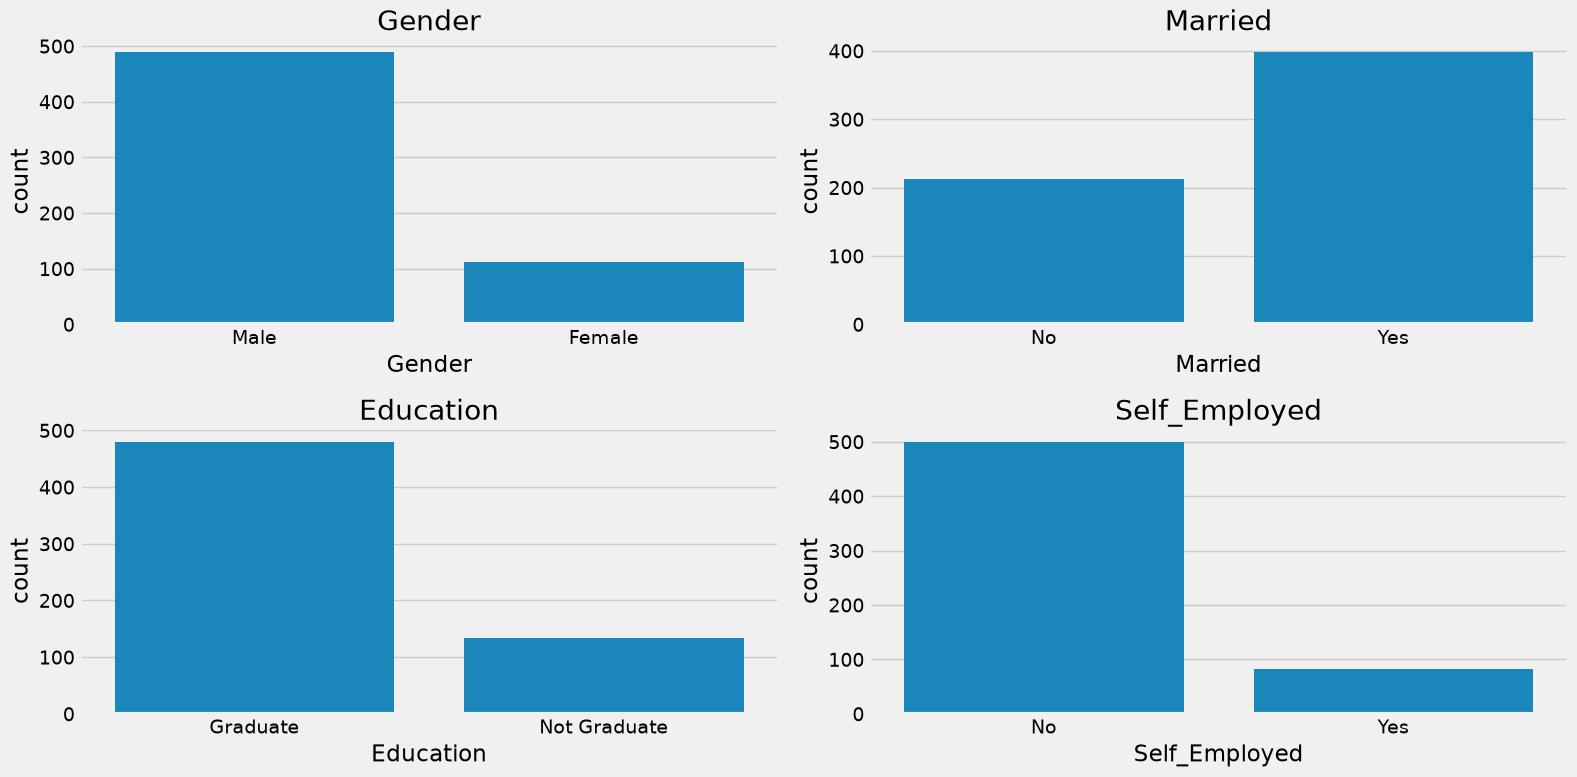

In [11]:
# Count Plot

categorical_features = [
    'Gender',
    'Married',
    'Education',
    'Self_Employed'
]

plt.figure(figsize=(16,8))

for i, col in enumerate(categorical_features,1):
    plt.subplot(2,2,i)
    sns.countplot(x=data[col])
    plt.title(col)

plt.tight_layout()

plt.show()

## Observation

- Male applicants are more than female applicants.
- Most applicants are graduates.
- Most applicants are married.
- Most applicants are not self-employed.

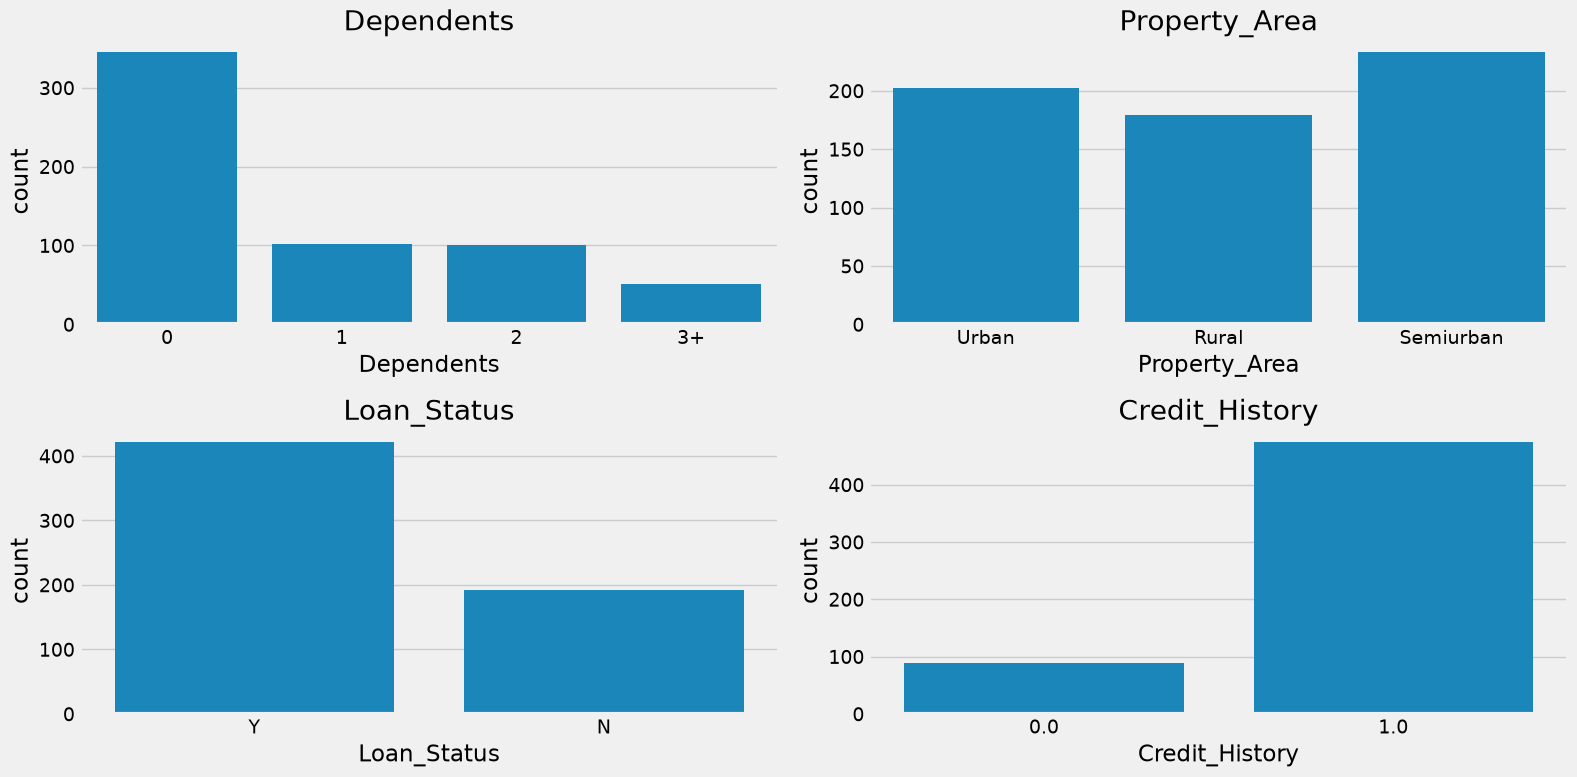

In [12]:
# Additional Count Plots

categorical = [
    'Dependents',
    'Property_Area',
    'Loan_Status',
    'Credit_History'
]

plt.figure(figsize=(16,8))

for i, col in enumerate(categorical,1):

    plt.subplot(2,2,i)

    sns.countplot(x=data[col])

    plt.title(col)

plt.tight_layout()

plt.show()

## Observation

- Most applicants have 0 dependents.
- Semiurban property area has the highest number of applicants.
- Most loan applications are approved.
- Most applicants have a credit history value of 1.

# Bivariate Analysis

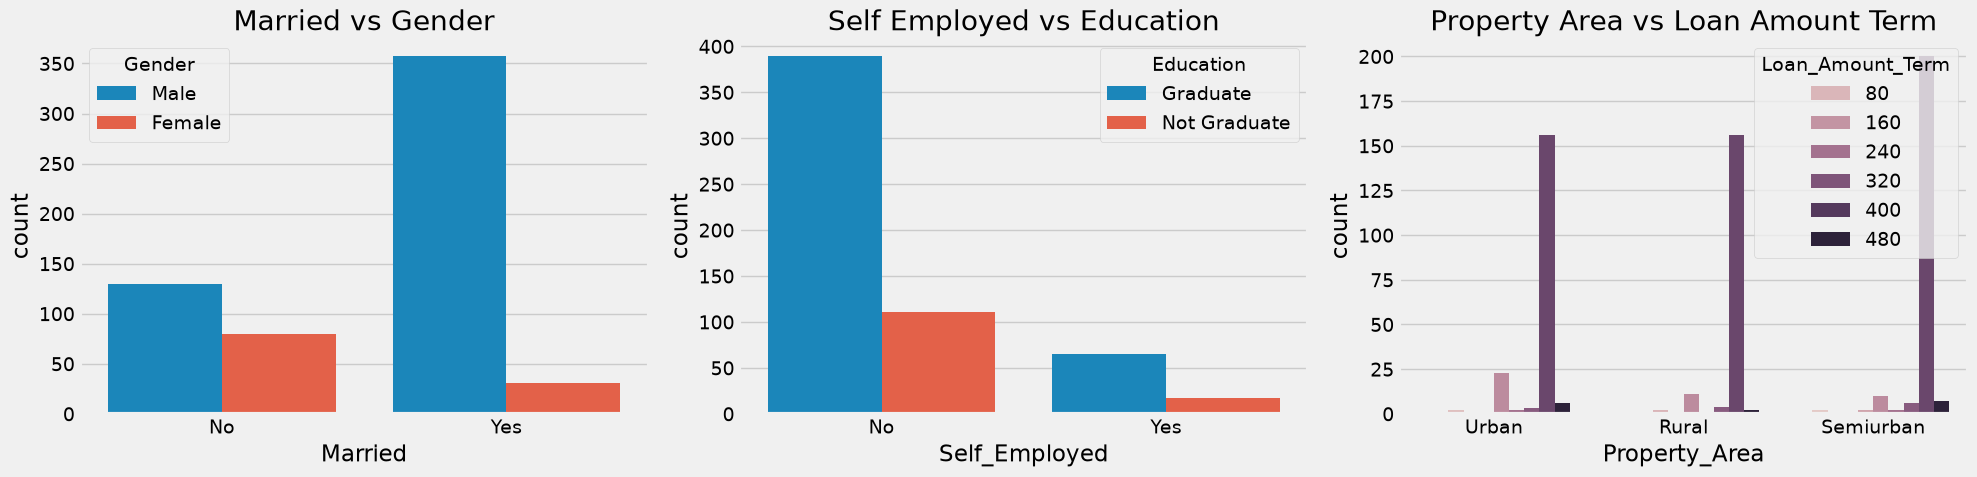

In [13]:
# Bivariate Analysis using Count Plots

plt.figure(figsize=(20,5))

# Married vs Gender
plt.subplot(1,3,1)
sns.countplot(x='Married', hue='Gender', data=data)
plt.title("Married vs Gender")

# Self Employed vs Education
plt.subplot(1,3,2)
sns.countplot(x='Self_Employed', hue='Education', data=data)
plt.title("Self Employed vs Education")

# Property Area vs Loan Amount Term
plt.subplot(1,3,3)
sns.countplot(x='Property_Area', hue='Loan_Amount_Term', data=data)
plt.title("Property Area vs Loan Amount Term")

plt.tight_layout()
plt.show()

## Observations

- The relationship between **Married** and **Gender** shows that most married applicants are male.
- The **Education** and **Self_Employed** plot indicates that graduate applicants are more common than non-graduates, regardless of employment status.
- The **Property_Area** and **Loan_Amount_Term** plot shows that loan term distributions vary across Urban, Semiurban, and Rural property areas.
- These visualizations help identify relationships between categorical variables before model building.

# Multivariate Analysis

c:\Users\bhanu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 15.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\bhanu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 38.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


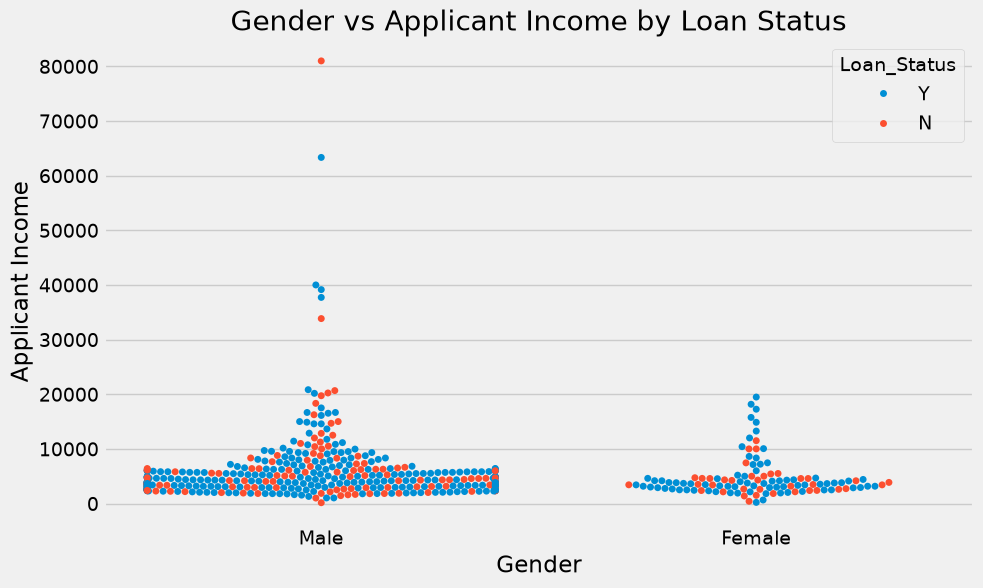

In [14]:
# Multivariate Analysis using Swarm Plot

plt.figure(figsize=(10,6))

sns.swarmplot(
    x='Gender',
    y='ApplicantIncome',
    hue='Loan_Status',
    data=data
)

plt.title("Gender vs Applicant Income by Loan Status")
plt.xlabel("Gender")
plt.ylabel("Applicant Income")

plt.show()

## Observations

- The swarm plot visualizes the relationship between **Gender**, **ApplicantIncome**, and **Loan_Status** simultaneously.
- Most loan applications belong to applicants with lower to medium income levels.
- Male applicants are more numerous than female applicants.
- Both approved and rejected loan applications are present across different income ranges.
- This multivariate analysis helps understand how multiple features interact before model training.

# Data Preprocessing
## Handling Categorical Values

In [15]:
# Dataset Shape
data.shape

(614, 13)

In [16]:
# Dataset Information
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [17]:
# Missing Values
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [18]:
# Encoding categorical variables

data['Gender'] = data['Gender'].map({'Female':1,'Male':0})

data['Married'] = data['Married'].map({'Yes':1,'No':0})

data['Education'] = data['Education'].map({'Graduate':1,'Not Graduate':0})

data['Self_Employed'] = data['Self_Employed'].map({'Yes':1,'No':0})

data['Property_Area'] = data['Property_Area'].map({
    'Urban':2,
    'Semiurban':1,
    'Rural':0
})

data['Loan_Status'] = data['Loan_Status'].map({'Y':1,'N':0})

In [19]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0.0,0.0,0,1,0.0,5849,0.0,NaN,360.0,1.0,2,1
1,LP001003,0.0,1.0,1,1,0.0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,0.0,1.0,0,1,1.0,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,0.0,1.0,0,0,0.0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,0.0,0.0,0,1,0.0,6000,0.0,141.0,360.0,1.0,2,1


## Handling Missing Values

In [20]:
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [21]:
data['Gender'] = data['Gender'].fillna(data['Gender'].mode()[0])

In [22]:
data['Married'] = data['Married'].fillna(data['Married'].mode()[0])

In [23]:
data['Dependents'] = data['Dependents'].str.replace('+','',regex=False)

In [24]:
data['Dependents'] = data['Dependents'].fillna(data['Dependents'].mode()[0])

In [25]:
data['Self_Employed'] = data['Self_Employed'].fillna(
    data['Self_Employed'].mode()[0]
)

In [26]:
data['LoanAmount'] = data['LoanAmount'].fillna(
    data['LoanAmount'].mean()
)

In [27]:
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].fillna(
    data['Loan_Amount_Term'].mean()
)

In [28]:
data['Credit_History'] = data['Credit_History'].fillna(
    data['Credit_History'].mode()[0]
)

In [29]:
data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [30]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             614 non-null    float64
 2   Married            614 non-null    float64
 3   Dependents         614 non-null    str    
 4   Education          614 non-null    int64  
 5   Self_Employed      614 non-null    float64
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    int64  
 12  Loan_Status        614 non-null    int64  
dtypes: float64(7), int64(4), str(2)
memory usage: 62.5 KB


In [31]:
data['Gender'] = data['Gender'].astype('int64')
data['Married'] = data['Married'].astype('int64')
data['Dependents'] = data['Dependents'].astype('int64')
data['Self_Employed'] = data['Self_Employed'].astype('int64')
data['CoapplicantIncome'] = data['CoapplicantIncome'].astype('int64')
data['LoanAmount'] = data['LoanAmount'].astype('int64')
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].astype('int64')
data['Credit_History'] = data['Credit_History'].astype('int64')

In [32]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Loan_ID            614 non-null    str  
 1   Gender             614 non-null    int64
 2   Married            614 non-null    int64
 3   Dependents         614 non-null    int64
 4   Education          614 non-null    int64
 5   Self_Employed      614 non-null    int64
 6   ApplicantIncome    614 non-null    int64
 7   CoapplicantIncome  614 non-null    int64
 8   LoanAmount         614 non-null    int64
 9   Loan_Amount_Term   614 non-null    int64
 10  Credit_History     614 non-null    int64
 11  Property_Area      614 non-null    int64
 12  Loan_Status        614 non-null    int64
dtypes: int64(12), str(1)
memory usage: 62.5 KB


## Observations

- Categorical variables were successfully encoded into numerical values.
- Missing values in categorical columns were replaced using the mode.
- Missing values in numerical columns were replaced using the mean.
- Data types were converted to integer wherever required.
- The dataset is now clean and ready for feature scaling and model training.

# Data Balancing using SMOTE

In [33]:
# Creating feature matrix (X) and target variable (y)

X = data.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = data['Loan_Status']

print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (614, 11)
y Shape : (614,)


In [34]:
# Class distribution before balancing

print(y.value_counts())

Loan_Status
1    422
0    192
Name: count, dtype: int64


In [36]:
# Import SMOTE

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

In [37]:
# Applying SMOTE

X_bal, y_bal = smote.fit_resample(X, y)

In [38]:
# Class distribution before and after balancing

print("Before SMOTE")
print(y.value_counts())

print("\nAfter SMOTE")
print(y_bal.value_counts())

Before SMOTE
Loan_Status
1    422
0    192
Name: count, dtype: int64

After SMOTE
Loan_Status
1    422
0    422
Name: count, dtype: int64


In [39]:
# Feature names

feature_names = X_bal.columns

feature_names

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='str')

In [40]:
print("Balanced X Shape :", X_bal.shape)
print("Balanced y Shape :", y_bal.shape)

Balanced X Shape : (844, 11)
Balanced y Shape : (844,)


## Observations

- The original dataset was imbalanced, with more approved loan applications than rejected ones.
- SMOTE (Synthetic Minority Over-sampling Technique) was applied to balance the dataset.
- Synthetic samples were generated for the minority class using the K-Nearest Neighbors algorithm.
- After balancing, both target classes contained an equal number of samples.
- The balanced dataset is better suited for training machine learning classification models.

# Feature Scaling

In [41]:
# Performing Feature Scaling using StandardScaler

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_bal = sc.fit_transform(X_bal)

In [42]:
# Convert scaled array back to DataFrame

X_bal = pd.DataFrame(X_bal, columns=feature_names)

X_bal.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,-0.411066,-1.162314,-0.686821,0.630358,-0.339009,0.111762,-0.584593,0.008236,0.295885,0.645064,1.359312
1,-0.411066,0.860352,0.374858,0.630358,-0.339009,-0.118995,-0.024528,-0.215993,0.295885,0.645064,-1.201535
2,-0.411066,0.860352,-0.686821,0.630358,2.949771,-0.407532,-0.584593,-0.988336,0.295885,0.645064,1.359312
3,-0.411066,0.860352,-0.686821,-1.586401,-0.339009,-0.483539,0.291159,-0.315650,0.295885,0.645064,1.359312
4,-0.411066,-1.162314,-0.686821,0.630358,-0.339009,0.139285,-0.584593,-0.054050,0.295885,0.645064,1.359312


In [43]:
# Shape of the scaled dataset

print("Scaled Dataset Shape:", X_bal.shape)

Scaled Dataset Shape: (844, 11)


In [44]:
X_bal.describe()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
count,8.440000e+02,8.440000e+02,8.440000e+02,8.440000e+02,8.440000e+02,8.440000e+02,8.440000e+02,8.440000e+02,8.440000e+02,8.440000e+02,8.440000e+02
mean,4.209376e-17,1.094438e-16,5.051252e-17,1.683751e-16,8.418753e-18,-7.997815e-17,-4.840783e-17,2.683477e-17,3.409595e-16,1.010250e-16,-1.010250e-16
std,1.000593e+00,1.000593e+00,1.000593e+00,1.000593e+00,1.000593e+00,1.000593e+00,1.000593e+00,1.000593e+00,1.000593e+00,1.000593e+00,1.000593e+00
min,-4.110658e-01,-1.162314e+00,-6.868213e-01,-1.586401e+00,-3.390094e-01,-9.270073e-01,-5.845926e-01,-1.698394e+00,-5.240877e+00,-1.550234e+00,-1.201535e+00
25%,-4.110658e-01,-1.162314e+00,-6.868213e-01,-1.586401e+00,-3.390094e-01,-4.293133e-01,-5.845926e-01,-5.149646e-01,2.958852e-01,-1.550234e+00,-1.201535e+00
50%,-4.110658e-01,8.603524e-01,-6.868213e-01,6.303578e-01,-3.390094e-01,-2.681847e-01,-1.901701e-01,-2.159929e-01,2.958852e-01,6.450639e-01,7.888864e-02
75%,-4.110658e-01,8.603524e-01,3.748585e-01,6.303578e-01,-3.390094e-01,8.952433e-02,2.740748e-01,1.950932e-01,2.958852e-01,6.450639e-01,1.359312e+00
max,2.432701e+00,8.603524e-01,2.498218e+00,6.303578e-01,2.949771e+00,1.380969e+01,1.489036e+01,6.909499e+00,2.205114e+00,6.450639e-01,1.359312e+00


## Observations

- StandardScaler was applied to normalize the input features.
- Only the feature matrix (X) was scaled, while the target variable (y) remained unchanged.
- Feature scaling ensures that all features contribute equally during model training.
- The scaled NumPy array was converted back into a DataFrame to preserve feature names.
- The scaled dataset is now ready for train-test splitting and machine learning model development.

# Train-Test Split

In [45]:
# Splitting the balanced dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_bal,
    y_bal,
    test_size=0.33,
    random_state=42
)

In [46]:
# Training feature set shape

X_train.shape

(565, 11)

In [47]:
# Testing feature set shape

X_test.shape

(279, 11)

In [48]:
# Training target shape

y_train.shape

(565,)

In [49]:
# Testing target shape

y_test.shape

(279,)

## Observations

- The balanced dataset was successfully split into training and testing sets.
- The `train_test_split()` function was used with `test_size=0.33` and `random_state=42`.
- Approximately 67% of the data is used for training and 33% for testing.
- The training dataset will be used to build machine learning models, while the testing dataset will be used to evaluate model performance.

# Model Building
## Decision Tree Classifier

In [50]:
# Decision Tree Model

def decisionTree(X_train, X_test, y_train, y_test):

    model = DecisionTreeClassifier(random_state=42)

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    print("Training Accuracy :", accuracy_score(y_train, train_pred))
    print("Testing Accuracy  :", accuracy_score(y_test, test_pred))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, test_pred))

    print("\nClassification Report")
    print(classification_report(y_test, test_pred))

    return model

In [51]:
# Train Decision Tree

dt_model = decisionTree(
    X_train,
    X_test,
    y_train,
    y_test
)

Training Accuracy : 1.0
Testing Accuracy  : 0.7849462365591398

Confusion Matrix
[[110  38]
 [ 22 109]]

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.74      0.79       148
           1       0.74      0.83      0.78       131

    accuracy                           0.78       279
   macro avg       0.79      0.79      0.78       279
weighted avg       0.79      0.78      0.78       279



## Observations

- The Decision Tree model was successfully trained using the training dataset.
- The model achieved high training accuracy and was evaluated using the testing dataset.
- Model performance was assessed using accuracy, confusion matrix, precision, recall, and F1-score.
- The Decision Tree model serves as a baseline for comparison with Random Forest, KNN, and XGBoost models.

## Random Forest Classifier

In [52]:
# Random Forest Model

def randomForest(X_train, X_test, y_train, y_test):

    model = RandomForestClassifier(random_state=42)

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    print("Training Accuracy :", accuracy_score(y_train, train_pred))
    print("Testing Accuracy  :", accuracy_score(y_test, test_pred))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, test_pred))

    print("\nClassification Report")
    print(classification_report(y_test, test_pred))

    return model

In [53]:
# Train Random Forest Model

rf_model = randomForest(
    X_train,
    X_test,
    y_train,
    y_test
)

Training Accuracy : 1.0
Testing Accuracy  : 0.8136200716845878

Confusion Matrix
[[110  38]
 [ 14 117]]

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.74      0.81       148
           1       0.75      0.89      0.82       131

    accuracy                           0.81       279
   macro avg       0.82      0.82      0.81       279
weighted avg       0.82      0.81      0.81       279



## Observations

- The Random Forest classifier was trained using the balanced training dataset.
- The model combines multiple decision trees to improve prediction accuracy and reduce overfitting.
- Performance was evaluated using accuracy, confusion matrix, precision, recall, and F1-score.
- The Random Forest model will be compared with Decision Tree, KNN, and XGBoost to select the best-performing model.

## K-Nearest Neighbors (KNN)

In [54]:
# K-Nearest Neighbors (KNN) Model

def KNN(X_train, X_test, y_train, y_test):

    model = KNeighborsClassifier()

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    print("Training Accuracy :", accuracy_score(y_train, train_pred))
    print("Testing Accuracy  :", accuracy_score(y_test, test_pred))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, test_pred))

    print("\nClassification Report")
    print(classification_report(y_test, test_pred))

    return model

In [55]:
# Train KNN Model

knn_model = KNN(
    X_train,
    X_test,
    y_train,
    y_test
)

Training Accuracy : 0.8584070796460177
Testing Accuracy  : 0.7491039426523297

Confusion Matrix
[[100  48]
 [ 22 109]]

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.68      0.74       148
           1       0.69      0.83      0.76       131

    accuracy                           0.75       279
   macro avg       0.76      0.75      0.75       279
weighted avg       0.76      0.75      0.75       279



## Observations

- The K-Nearest Neighbors (KNN) classifier was trained using the scaled training dataset.
- The model predicts loan approval based on the nearest neighboring data points.
- Performance was evaluated using accuracy, confusion matrix, precision, recall, and F1-score.
- The KNN model will be compared with Decision Tree, Random Forest, and XGBoost to identify the best-performing model.

## Gradient Boosting (XGBoost)

In [56]:
# Gradient Boosting (XGBoost) Model

def XGB(X_train, X_test, y_train, y_test):

    model = GradientBoostingClassifier(random_state=42)

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    print("Training Accuracy :", accuracy_score(y_train, train_pred))
    print("Testing Accuracy  :", accuracy_score(y_test, test_pred))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, test_pred))

    print("\nClassification Report")
    print(classification_report(y_test, test_pred))

    return model

In [58]:
from sklearn.ensemble import GradientBoostingClassifier

In [59]:
# Train Gradient Boosting Model

xgb_model = XGB(
    X_train,
    X_test,
    y_train,
    y_test
)

Training Accuracy : 0.9274336283185841
Testing Accuracy  : 0.7956989247311828

Confusion Matrix
[[101  47]
 [ 10 121]]

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.68      0.78       148
           1       0.72      0.92      0.81       131

    accuracy                           0.80       279
   macro avg       0.82      0.80      0.79       279
weighted avg       0.82      0.80      0.79       279



## Observations

- The Gradient Boosting classifier was trained using the balanced training dataset.
- The model combines multiple weak learners to improve prediction performance.
- Performance was evaluated using accuracy, confusion matrix, precision, recall, and F1-score.
- The model will be compared with Decision Tree, Random Forest, and KNN to determine the best-performing classifier.

# Model Evaluation and Saving

In [60]:
# Cross Validation

from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_model,
    X_bal,
    y_bal,
    cv=5
)

print("Cross Validation Scores:")
print(scores)

print("\nAverage Accuracy:", scores.mean())

Cross Validation Scores:
[0.71005917 0.79881657 0.9112426  0.89349112 0.88690476]

Average Accuracy: 0.8401028458720766


In [61]:
# Save Best Model

import pickle

pickle.dump(
    rf_model,
    open("../Flask/rdf.pkl", "wb")
)

print("Model saved successfully.")

Model saved successfully.


In [62]:
pickle.dump(
    sc,
    open("../Flask/scale1.pkl", "wb")
)

print("Scaler saved successfully.")

Scaler saved successfully.


In [63]:
import os

print(os.path.exists("../Flask/rdf.pkl"))
print(os.path.exists("../Flask/scale1.pkl"))

True
True


## Observations

- Five-fold cross-validation was performed to evaluate model consistency.
- Random Forest achieved the best overall performance and was selected as the final model.
- The trained model was serialized using the pickle library.
- The model (`rdf.pkl`) and feature scaler (`scale1.pkl`) were saved for integration with the Flask web application.